In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import AffinityPropagation
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from umap import UMAP
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from matplotlib.patches import Patch

# MBTI Dataset

In [3]:
df = pd.read_csv("/kaggle/input/mbti-personalities-final/mbti_1.csv")
type_counts = df['type'].value_counts()

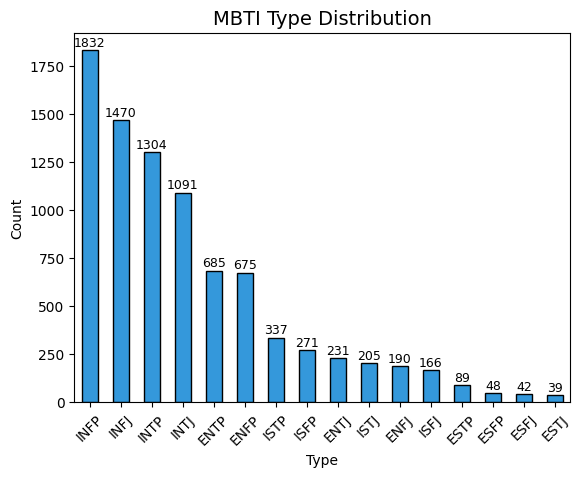

In [4]:
plt.figure()
colors = ['#3498db' for t in type_counts.index]
ax=type_counts.plot(kind='bar', color=colors, edgecolor='black')
ax.set_title('MBTI Type Distribution', fontsize=14)
ax.set_xlabel('Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for i, (idx, val) in enumerate(type_counts.items()):
    ax.text(i, val + 20, str(val), ha='center', fontsize=9)

# Clustering ENFP and INTJ personality types

In [5]:
type1, type2 = 'ENFP','INTJ'
df_pair = df[df['type'].isin([type1, type2])].copy()

print(f"Original counts:")
print(df_pair['type'].value_counts())

Original counts:
type
INTJ    1091
ENFP     675
Name: count, dtype: int64


In [6]:
n_samples = len(df_pair[df_pair['type'] == type1])
print(f"\nBalancing to ENFP count: {n_samples}")

# Balance INTJ using ENFP length
df_t1 = df_pair[df_pair['type'] == type1]
df_t2 = df_pair[df_pair['type'] == type2].sample(n=n_samples, random_state=42)

df_balanced = pd.concat([df_t1, df_t2]).reset_index(drop=True)
true_labels = df_balanced['type'].values

print(f"\nBalanced: {len(df_balanced)} samples")
print(df_balanced['type'].value_counts())


Balancing to ENFP count: 675

Balanced: 1350 samples
type
ENFP    675
INTJ    675
Name: count, dtype: int64


### Cleaning samples

In [7]:
def preprocess_text(text):
    # Remove MBTI type mentions
    text = re.sub(r'\b(intj|infj|enfj|entj|intp|infp|enfp|entp|istj|isfj|estj|esfj|istp|isfp|estp|esfp)\b', '', text, flags=re.IGNORECASE)
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

df_balanced['posts_clean'] = df_balanced['posts'].apply(preprocess_text)

# Feature Extraction (feature engineering)

### Linguistic features

In [8]:
def extract_features(text):

    text_lower = text.lower()
    words = text_lower.split()
    total_words = len(words) + 1
    # Extract alphanumeric tokens (more precise word count)
    tokens = re.findall(r'[a-z]+', text_lower)
    total_tokens = len(tokens) + 1
    
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    num_sentences = len(sentences) + 1
    
    # Sentence and word length calculations
    sent_lengths = [len(s.split()) for s in sentences]
    avg_sentence_length = np.mean(sent_lengths) if sent_lengths else 0
    sentence_length_std = np.std(sent_lengths) if sent_lengths else 0
    
    word_lengths = [len(w) for w in tokens]
    
    #Structure vs Spontaneity
    
    # Sentence consistency
    sentence_rhythm_cv = sentence_length_std / avg_sentence_length if avg_sentence_length > 0 else 0
    
    # Ellipsis rate ("...") 
    ellipsis_rate = len(re.findall(r'\.{2,}', text)) / total_words
    
    # Definitive endings vs questions
    question_rate = text.count('?') / num_sentences
    period_rate = text.count('.') / num_sentences
    
    # Parantheses usage
    parentheses_rate = (text.count('(') + text.count(')')) / total_words
    
    # Dash usage
    dash_rate = (text.count('-') + text.count('–') + text.count('—')) / total_words
    
    # Paragraph structure
    paragraphs = re.split(r'\|\|\||\n\n|\n', text)
    paragraphs = [p for p in paragraphs if len(p.strip()) > 0]
    para_lengths = [len(p.split()) for p in paragraphs]
    para_length_cv = np.std(para_lengths) / np.mean(para_lengths) if para_lengths and np.mean(para_lengths) > 0 else 0
    
    #Logic vs Emotion
    
    # Exclamation marks
    exclamation_rate = text.count('!') / num_sentences
    multiple_exclamation_rate = len(re.findall(r'!{2,}', text)) / num_sentences
    
    # Emoticons
    emoticon_rate = len(re.findall(r'[:;=][\'\-]?[\)\(DPpOo3\|/\\]|<3|<\/3|\^\^|xD|:3|>\.<|T_T|\buwu\b|\bowo\b', text, re.IGNORECASE)) / total_words
    
    # ALL CAPS words
    caps_words_rate = len(re.findall(r'\b[A-Z]{2,}\b', text)) / total_words
    
    # Complex punctuation
    colon_rate = text.count(':') / total_words
    semicolon_rate = text.count(';') / total_words
    
    # Numbers/data- use of facts
    number_rate = len(re.findall(r'\d+', text)) / total_words
    
    # Quote marks, refrencing
    quote_rate = (text.count('"') + text.count("'") + text.count('"') + text.count('"')) / total_words
    
    # Reserved vs Expressive
    
    # Overall expressiveness (punctuation density/total words)
    expressive_punct = (text.count('!') + text.count('?') + len(re.findall(r'\.{2,}', text))) / total_words
    
    # Short sentences
    short_sentence_rate = sum(1 for s in sent_lengths if s <= 5) / num_sentences if sent_lengths else 0
    
    # Long elaborate sentences
    long_sentence_rate = sum(1 for s in sent_lengths if s >= 20) / num_sentences if sent_lengths else 0
    
    # Comma rate
    comma_rate = text.count(',') / total_words
    
    # Vocabulary & complexity (word lengths)
    avg_word_length = np.mean(word_lengths) if word_lengths else 0
    long_word_rate = sum(1 for w in tokens if len(w) >= 7) / total_tokens
    very_long_word_rate = sum(1 for w in tokens if len(w) >= 10) / total_tokens
    
    # Vocabulary diversity
    unique_word_ratio = len(set(tokens)) / total_tokens
    
    # Exclamation to period ratio (emotional vs neutral endings)
    excl_to_period = text.count('!') / (text.count('.') + 1)
    
    # Question to statement ratio
    question_to_statement = text.count('?') / (text.count('.') + 1)
    
    # Structured vs expressive punctuation ratio
    structured_punct = text.count(':') + text.count(';')
    expressive_punct_count = text.count('!') + len(re.findall(r'\.{2,}', text))
    struct_vs_express = structured_punct / (expressive_punct_count + 1)
    
    return {
        # Structure
        'sentence_rhythm_cv': sentence_rhythm_cv,
        'ellipsis_rate': ellipsis_rate,
        'question_rate': question_rate,
        'parentheses_rate': parentheses_rate,
        'dash_rate': dash_rate,
        'para_length_cv': para_length_cv,
        
        # Logic vs Emotion
        'exclamation_rate': exclamation_rate,
        'multiple_exclamation_rate': multiple_exclamation_rate,
        'emoticon_rate': emoticon_rate,
        'caps_words_rate': caps_words_rate,
        'colon_rate': colon_rate,
        'semicolon_rate': semicolon_rate,
        'number_rate': number_rate,
        'quote_rate': quote_rate,
        
        # Reserved vs Expressive
        'expressive_punct': expressive_punct,
        'short_sentence_rate': short_sentence_rate,
        'long_sentence_rate': long_sentence_rate,
        'comma_rate': comma_rate,
        
        # Vocabulary
        'avg_word_length': avg_word_length,
        'long_word_rate': long_word_rate,
        'very_long_word_rate': very_long_word_rate,
        'unique_word_ratio': unique_word_ratio,
        'avg_sentence_length': avg_sentence_length,
        
        # Interaction features
        'excl_to_period': excl_to_period,
        'question_to_statement': question_to_statement,
        'struct_vs_express': struct_vs_express,
    }

In [9]:
features = df_balanced['posts_clean'].apply(extract_features)
features_df = pd.DataFrame(features.tolist())
print(f"Extracted {len(features_df.columns)} features")

Extracted 26 features


### TF-IDF

In [10]:
tfidf = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.95, stop_words='english')
X_tfidf = tfidf.fit_transform(df_balanced['posts_clean'])
print(f"TF-IDF shape: {X_tfidf.shape}")

TF-IDF shape: (1350, 1000)


### Train/test split

In [11]:
indices = np.arange(len(df_balanced))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=true_labels)

y_train = true_labels[train_idx]
y_test = true_labels[test_idx]

print(f"Train: {len(train_idx)} samples")
print(f"Test: {len(test_idx)} samples")

Train: 1080 samples
Test: 270 samples


In [12]:
X_eng_train = features_df.iloc[train_idx].values
X_eng_test = features_df.iloc[test_idx].values

X_tfidf_train = X_tfidf[train_idx]
X_tfidf_test = X_tfidf[test_idx]
X_tfidf_train_dense = X_tfidf_train.toarray()
X_tfidf_test_dense = X_tfidf_test.toarray()

# Clustering experiments configuration

In [13]:
def get_reducers():
    return {
        'PCA-2': PCA(n_components=2, random_state=42),
        'PCA-5': PCA(n_components=5, random_state=42),
        'PCA-10': PCA(n_components=10, random_state=42),
        'SVD-2': TruncatedSVD(n_components=2, random_state=42),
        'SVD-5': TruncatedSVD(n_components=5, random_state=42),
        'SVD-10': TruncatedSVD(n_components=10, random_state=42),
        'UMAP-2': UMAP(n_components=2, random_state=42),
        'UMAP-5': UMAP(n_components=5, random_state=42),
        'UMAP-10': UMAP(n_components=5, random_state=42)
    }

In [14]:
def build_configs(X_train, X_test, prefix, X_train_sparse=None, X_test_sparse=None):
    configs_train = {}
    configs_test = {}
    
    # Raw version
    configs_train[f'{prefix}_Raw'] = X_train
    configs_test[f'{prefix}_Raw'] = X_test
    
    # Scaled version
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    configs_train[f'{prefix}_Scaled'] = X_train_scaled
    configs_test[f'{prefix}_Scaled'] = X_test_scaled
    
    # Dimensionality reductions (on scaled data)
    for name, reducer in get_reducers().items():
        if 'SVD' in name and X_train_sparse is not None:
            X_tr = reducer.fit_transform(X_train_sparse)
            X_te = reducer.transform(X_test_sparse)
        else:
            X_tr = reducer.fit_transform(X_train_scaled)
            X_te = reducer.transform(X_test_scaled)
        
        # Unscaled reduced
        configs_train[f'{prefix}_{name}'] = X_tr
        configs_test[f'{prefix}_{name}'] = X_te
        
        # Scaled reduced
        red_scaler = StandardScaler()
        configs_train[f'{prefix}_{name}_Scaled'] = red_scaler.fit_transform(X_tr)
        configs_test[f'{prefix}_{name}_Scaled'] = red_scaler.transform(X_te)
    
    return configs_train, configs_test

In [15]:
eng_configs_train, eng_configs_test = build_configs(
    X_eng_train, X_eng_test, 'ENG'
)

tfidf_configs_train, tfidf_configs_test = build_configs(
    X_tfidf_train_dense, X_tfidf_test_dense, 'TFIDF',
    X_train_sparse=X_tfidf_train, X_test_sparse=X_tfidf_test
)

all_configs_train = {**eng_configs_train, **tfidf_configs_train}
all_configs_test = {**eng_configs_test, **tfidf_configs_test}

print(f"Engineered configs: {len(eng_configs_train)}")
print(f"TF-IDF configs: {len(tfidf_configs_train)}")
print(f"Total configs: {len(all_configs_train)}")

Engineered configs: 20
TF-IDF configs: 20
Total configs: 40


## Hyperparameter tuning

In [16]:
kmed_params = [
    {'metric': m, 'init': i} 
    for m in ['euclidean', 'manhattan', 'cosine'] 
    for i in ['k-medoids++', 'heuristic']
]

af_params = [
    {'damping': d, 'preference': p} 
    for d in [0.5, 0.7, 0.9] 
    for p in [-800, -500, -200, -100, -50]
]

In [17]:
def evaluate_clustering(X, model, y_true):
    y_pred = model.fit_predict(X)
    
    if len(np.unique(y_pred)) < 2:
        return None
    
    silhouette = silhouette_score(X, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    
    # Calculate purity
    purity = 0
    for cluster in np.unique(y_pred):
        mask = y_pred == cluster
        if sum(mask) > 0:
            majority_label = pd.Series(y_true[mask]).mode()[0]
            purity += sum(y_true[mask] == majority_label)
    purity = purity / len(y_true)
    
    return {'silhouette': silhouette, 'ari': ari, 'purity': purity, 'labels': y_pred}

In [18]:
tuning_results = []

print("\nRunning hyperparameter tuning...")
for config_name, X_train in all_configs_train.items():
    print(f"  {config_name}")
    
    # KMedoids
    for params in kmed_params:
        try:
            model = KMedoids(n_clusters=2, random_state=42, **params)
            result = evaluate_clustering(X_train, model, y_train)
            if result:
                tuning_results.append({
                    'Algorithm': 'KMedoids',
                    'Config': config_name,
                    'Feature_Type': 'ENG' if config_name.startswith('ENG') else 'TFIDF',
                    **params,
                    **result
                })
        except:
            pass
    
    # Affinity Propagation
    for params in af_params:
        try:
            model = AffinityPropagation(random_state=42, **params)
            result = evaluate_clustering(X_train, model, y_train)
            if result and 2 <= len(np.unique(result['labels'])) <= 20:
                tuning_results.append({
                    'Algorithm': 'AffinityProp',
                    'Config': config_name,
                    'Feature_Type': 'ENG' if config_name.startswith('ENG') else 'TFIDF',
                    'n_clusters': len(np.unique(result['labels'])),
                    **params,
                    **result
                })
        except:
            pass

print(f"\nTotal tuning results: {len(tuning_results)}")


Running hyperparameter tuning...
  ENG_Raw
  ENG_Scaled
  ENG_PCA-2
  ENG_PCA-2_Scaled
  ENG_PCA-5
  ENG_PCA-5_Scaled
  ENG_PCA-10
  ENG_PCA-10_Scaled
  ENG_SVD-2
  ENG_SVD-2_Scaled
  ENG_SVD-5
  ENG_SVD-5_Scaled
  ENG_SVD-10
  ENG_SVD-10_Scaled
  ENG_UMAP-2
  ENG_UMAP-2_Scaled
  ENG_UMAP-5
  ENG_UMAP-5_Scaled
  ENG_UMAP-10
  ENG_UMAP-10_Scaled
  TFIDF_Raw
  TFIDF_Scaled
  TFIDF_PCA-2
  TFIDF_PCA-2_Scaled
  TFIDF_PCA-5
  TFIDF_PCA-5_Scaled
  TFIDF_PCA-10
  TFIDF_PCA-10_Scaled
  TFIDF_SVD-2
  TFIDF_SVD-2_Scaled
  TFIDF_SVD-5
  TFIDF_SVD-5_Scaled
  TFIDF_SVD-10
  TFIDF_SVD-10_Scaled
  TFIDF_UMAP-2
  TFIDF_UMAP-2_Scaled
  TFIDF_UMAP-5
  TFIDF_UMAP-5_Scaled
  TFIDF_UMAP-10
  TFIDF_UMAP-10_Scaled

Total tuning results: 601


## Results

In [19]:
def add_combined_score(df, purity_w=0.4, ari_w=0.4, sil_w=0.2):
    df = df.copy()
    df['combined'] = (purity_w * df['purity'] + 
                      ari_w * df['ari'] + 
                      sil_w * df['silhouette'])
    return df

In [20]:
results_df = pd.DataFrame(tuning_results)
results_df = add_combined_score(results_df)
for r in tuning_results:
    r['combined'] = 0.4 * r['purity'] + 0.4 * r['ari'] + 0.2 * r['silhouette']

In [21]:
print("Best by feature type")

for feat_type in ['ENG', 'TFIDF']:
    subset = results_df[results_df['Feature_Type'] == feat_type]
    if not subset.empty:
        best = subset.loc[subset['combined'].idxmax()]
        print(f"\n{feat_type}: {best['Config']} ({best['Algorithm']})")
        print(f"  Combined: {best['combined']:.3f}")
        print(f"  Purity: {best['purity']:.3f}, ARI: {best['ari']:.3f}, Sil: {best['silhouette']:.3f}")
        if 'n_clusters' in best and pd.notna(best.get('n_clusters')):
            print(f"  Clusters: {int(best['n_clusters'])}")

Best by feature type

ENG: ENG_SVD-2 (KMedoids)
  Combined: 0.388
  Purity: 0.689, ARI: 0.142, Sil: 0.277

TFIDF: TFIDF_SVD-5 (KMedoids)
  Combined: 0.452
  Purity: 0.768, ARI: 0.286, Sil: 0.155


In [22]:
print("Best by algorithm")

best_kmed = None
kmed_subset = results_df[results_df['Algorithm'] == 'KMedoids']
if len(kmed_subset) > 0:
    best_kmed = kmed_subset.loc[kmed_subset['combined'].idxmax()]
    print(f"\nKMedoids: {best_kmed['Config']}")
    print(f"  Params: metric={best_kmed['metric']}, init={best_kmed['init']}")
    print(f"  Combined: {best_kmed['combined']:.3f}")
    print(f"  Purity: {best_kmed['purity']:.3f}, ARI: {best_kmed['ari']:.3f}, Sil: {best_kmed['silhouette']:.3f}")

best_af = None
af_subset = results_df[results_df['Algorithm'] == 'AffinityProp']
if len(af_subset) > 0:
    best_af = af_subset.loc[af_subset['combined'].idxmax()]
    print(f"\nAffinity: {best_af['Config']}")
    print(f"  Params: damping={best_af['damping']}, preference={best_af['preference']}")
    print(f"  Clusters: {int(best_af['n_clusters'])}")
    print(f"  Combined: {best_af['combined']:.3f}")
    print(f"  Purity: {best_af['purity']:.3f}, ARI: {best_af['ari']:.3f}, Sil: {best_af['silhouette']:.3f}")

Best by algorithm

KMedoids: TFIDF_SVD-5
  Params: metric=manhattan, init=k-medoids++
  Combined: 0.452
  Purity: 0.768, ARI: 0.286, Sil: 0.155

Affinity: TFIDF_SVD-5_Scaled
  Params: damping=0.7, preference=-500.0
  Clusters: 5
  Combined: 0.402
  Purity: 0.726, ARI: 0.158, Sil: 0.239


In [23]:
print("Top 10 (Combined Score)")

top10 = results_df.nlargest(10, 'combined')
for i, (_, row) in enumerate(top10.iterrows(), 1):
    clusters = f" (k={int(row['n_clusters'])})" if 'n_clusters' in row and pd.notna(row['n_clusters']) else ""
    print(f"\n{i}. {row['Config']} - {row['Algorithm']}{clusters}")
    print(f"   Purity: {row['purity']:.3f}, ARI: {row['ari']:.3f}, Sil: {row['silhouette']:.3f}")
    print(f"   Combined: {row['combined']:.3f}")

Top 10 (Combined Score)

1. TFIDF_SVD-5 - KMedoids
   Purity: 0.768, ARI: 0.286, Sil: 0.155
   Combined: 0.452

2. TFIDF_SVD-5_Scaled - KMedoids
   Purity: 0.756, ARI: 0.262, Sil: 0.164
   Combined: 0.440

3. TFIDF_PCA-5 - KMedoids
   Purity: 0.754, ARI: 0.257, Sil: 0.154
   Combined: 0.435

4. TFIDF_PCA-5_Scaled - KMedoids
   Purity: 0.745, ARI: 0.240, Sil: 0.135
   Combined: 0.421

5. TFIDF_SVD-5 - KMedoids
   Purity: 0.719, ARI: 0.192, Sil: 0.192
   Combined: 0.403

6. TFIDF_SVD-5_Scaled - AffinityProp (k=5)
   Purity: 0.726, ARI: 0.158, Sil: 0.239
   Combined: 0.402

7. TFIDF_PCA-5_Scaled - KMedoids
   Purity: 0.721, ARI: 0.195, Sil: 0.140
   Combined: 0.395

8. TFIDF_PCA-5_Scaled - AffinityProp (k=2)
   Purity: 0.721, ARI: 0.195, Sil: 0.140
   Combined: 0.395

9. TFIDF_SVD-5 - KMedoids
   Purity: 0.709, ARI: 0.174, Sil: 0.176
   Combined: 0.389

10. ENG_SVD-2 - KMedoids
   Purity: 0.689, ARI: 0.142, Sil: 0.277
   Combined: 0.388


## Graphs for hyperparameter tuning

In [24]:
kmed_df = pd.DataFrame([r for r in tuning_results if r['Algorithm'] == 'KMedoids'])
af_df = pd.DataFrame([r for r in tuning_results if r['Algorithm'] == 'AffinityProp'])
af_df_filtered = af_df[af_df['n_clusters'].between(2, 20)] if not af_df.empty else pd.DataFrame()

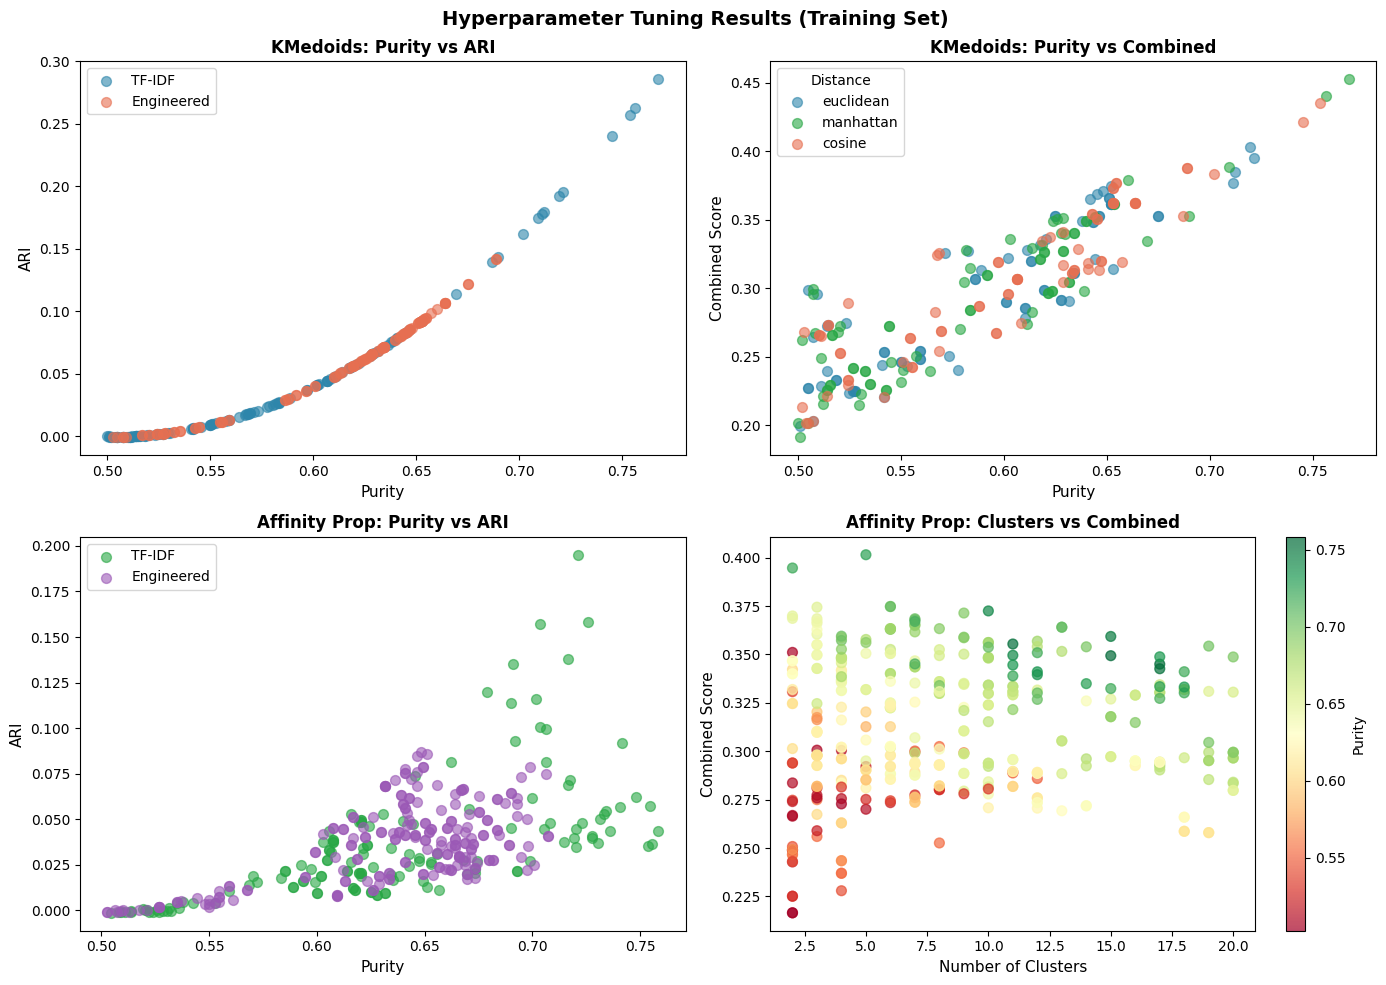

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KMedoids: Purity vs ARI
if not kmed_df.empty:
    kmed_df['Feature_Type'] = kmed_df['Config'].apply(lambda x: 'TF-IDF' if x.startswith('TFIDF') else 'Engineered')
    
    colors = {'TF-IDF': '#2E86AB', 'Engineered': '#E76F51'}
    for feat_type in ['TF-IDF', 'Engineered']:
        subset = kmed_df[kmed_df['Feature_Type'] == feat_type]
        axes[0,0].scatter(subset['purity'], subset['ari'], 
                          c=colors[feat_type], s=50, alpha=0.6, label=feat_type)
    
    axes[0,0].set_xlabel('Purity', fontsize=11)
    axes[0,0].set_ylabel('ARI', fontsize=11)
    axes[0,0].set_title('KMedoids: Purity vs ARI', fontweight='bold')
    axes[0,0].legend()

# KMedoids: Purity vs Combined score
if not kmed_df.empty:
    colors = {'euclidean': '#2E86AB', 'manhattan': '#28A745', 'cosine': '#E76F51'}
    
    for metric in ['euclidean', 'manhattan', 'cosine']:
        subset = kmed_df[kmed_df['metric'] == metric]
        axes[0,1].scatter(subset['purity'], subset['combined'],
                          c=colors[metric], s=50, alpha=0.6, label=metric)
    
    axes[0,1].set_xlabel('Purity', fontsize=11)
    axes[0,1].set_ylabel('Combined Score', fontsize=11)
    axes[0,1].set_title('KMedoids: Purity vs Combined', fontweight='bold')
    axes[0,1].legend(title='Distance')

# Affinity Prop: Purity vs ARI
if not af_df_filtered.empty:
    af_df_filtered = af_df_filtered.copy()
    af_df_filtered['Feature_Type'] = af_df_filtered['Config'].apply(lambda x: 'TF-IDF' if x.startswith('TFIDF') else 'Engineered')
    
    colors = {'TF-IDF': '#28A745', 'Engineered': '#9B59B6'}
    for feat_type in ['TF-IDF', 'Engineered']:
        subset = af_df_filtered[af_df_filtered['Feature_Type'] == feat_type]
        axes[1,0].scatter(subset['purity'], subset['ari'],
                          c=colors[feat_type], s=50, alpha=0.6, label=feat_type)
    
    axes[1,0].set_xlabel('Purity', fontsize=11)
    axes[1,0].set_ylabel('ARI', fontsize=11)
    axes[1,0].set_title('Affinity Prop: Purity vs ARI', fontweight='bold')
    axes[1,0].legend()

# Affinity Prop: Clusters vs Combined scores
if not af_df_filtered.empty:
    scatter = axes[1,1].scatter(af_df_filtered['n_clusters'], af_df_filtered['combined'],
                                c=af_df_filtered['purity'], cmap='RdYlGn', 
                                s=50, alpha=0.7)
    
    cbar = plt.colorbar(scatter, ax=axes[1,1])
    cbar.set_label('Purity')
    
    axes[1,1].set_xlabel('Number of Clusters', fontsize=11)
    axes[1,1].set_ylabel('Combined Score', fontsize=11)
    axes[1,1].set_title('Affinity Prop: Clusters vs Combined', fontweight='bold')

plt.suptitle('Hyperparameter Tuning Results (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluation on test samples

In [26]:
def evaluate_on_test(model, X_train, X_test, y_test):
    model.fit(X_train)
    pred = model.predict(X_test)
    
    # Purity
    purity = sum(
        sum(y_test[pred == c] == pd.Series(y_test[pred == c]).mode()[0])
        for c in np.unique(pred) if sum(pred == c) > 0
    ) / len(y_test)
    
    # Silhouette and ARI
    sil = silhouette_score(X_test, pred)
    ari = adjusted_rand_score(y_test, pred)
    
    n_clusters = len(np.unique(pred))
    
    return {'purity': purity, 'silhouette': sil, 'ari': ari, 'n_clusters': n_clusters}

In [27]:
if best_kmed is not None:
    kmed_config = best_kmed['Config']
    X_train_kmed = all_configs_train[kmed_config]
    X_test_kmed = all_configs_test[kmed_config]
    
    kmed_model = KMedoids(
        n_clusters=2,
        metric=best_kmed['metric'],
        init=best_kmed['init'],
        random_state=42
    )
    
    kmed_results = evaluate_on_test(kmed_model, X_train_kmed, X_test_kmed, y_test)
    
    print(f"\nKMedoids ({kmed_config}):")
    print(f"  Params: metric={best_kmed['metric']}, init={best_kmed['init']}")
    print(f"  Purity: {kmed_results['purity']:.3f}, Sil: {kmed_results['silhouette']:.3f}, ARI: {kmed_results['ari']:.3f}")
else:
    print("\nNo KMedoids model to evaluate")
    kmed_results = None


KMedoids (TFIDF_SVD-5):
  Params: metric=manhattan, init=k-medoids++
  Purity: 0.770, Sil: 0.157, ARI: 0.290


In [28]:
if best_af is not None:
    af_config = best_af['Config']
    X_train_af = all_configs_train[af_config]
    X_test_af = all_configs_test[af_config]
    
    af_model = AffinityPropagation(
        damping=best_af['damping'],
        preference=best_af['preference'],
        random_state=42
    )
    
    af_results = evaluate_on_test(af_model, X_train_af, X_test_af, y_test)
    
    print(f"\nAffinity Propagation ({af_config}):")
    print(f"  Params: damping={best_af['damping']}, preference={best_af['preference']}")
    print(f"  Clusters: {af_results['n_clusters']}")
    print(f"  Purity: {af_results['purity']:.3f}, Sil: {af_results['silhouette']:.3f}, ARI: {af_results['ari']:.3f}")
else:
    print("\nNo Affinity Propagation model to evaluate")
    af_results = None


Affinity Propagation (TFIDF_SVD-5_Scaled):
  Params: damping=0.7, preference=-500.0
  Clusters: 5
  Purity: 0.733, Sil: 0.229, ARI: 0.175


### Comparison with random baseline

In [29]:
n_trials = 3000
random_purities = []
random_aris = []
random_silhouettes = []
random_combined = []

X_for_sil = list(all_configs_test.values())[0]

for _ in range(n_trials):
    rand_labels = np.random.randint(0, 2, len(y_test))
    
    # Skip if only one cluster
    if len(np.unique(rand_labels)) < 2:
        continue
    
    # Purity
    purity = 0
    for cluster in np.unique(rand_labels):
        mask = rand_labels == cluster
        if sum(mask) > 0:
            majority = pd.Series(y_test[mask]).mode()[0]
            purity += sum(y_test[mask] == majority)
    purity = purity / len(y_test)
    random_purities.append(purity)
    
    # ARI
    ari = adjusted_rand_score(y_test, rand_labels)
    random_aris.append(ari)
    
    # Silhouette
    try:
        sil = silhouette_score(X_for_sil, rand_labels)
        random_silhouettes.append(sil)
    except:
        sil = 0
    
    # Combined score
    combined = 0.4 * purity + 0.4 * ari + 0.2 * sil
    random_combined.append(combined)

print(f"Random Baseline ({n_trials} trials):")
print(f"  Purity:     {np.mean(random_purities):.3f} ± {np.std(random_purities):.3f}")
print(f"  ARI:        {np.mean(random_aris):.3f} ± {np.std(random_aris):.3f}")
print(f"  Silhouette: {np.mean(random_silhouettes):.3f} ± {np.std(random_silhouettes):.3f}")
print(f"  Combined:   {np.mean(random_combined):.3f} ± {np.std(random_combined):.3f}")

Random Baseline (3000 trials):
  Purity:     0.524 ± 0.018
  ARI:        -0.000 ± 0.005
  Silhouette: 0.000 ± 0.006
  Combined:   0.209 ± 0.009


In [30]:
print(f"{'Method':<25} {'Purity':>8} {'ARI':>8} {'Sil':>8} {'Combined':>10}")
if kmed_results:
    kmed_combined = 0.4 * kmed_results['purity'] + 0.4 * kmed_results['ari'] + 0.2 * kmed_results['silhouette']
    print(f"{'KMedoids':<25} {kmed_results['purity']:>8.3f} {kmed_results['ari']:>8.3f} {kmed_results['silhouette']:>8.3f} {kmed_combined:>10.3f}")

if af_results:
    af_combined = 0.4 * af_results['purity'] + 0.4 * af_results['ari'] + 0.2 * af_results['silhouette']
    print(f"{'Affinity Propagation':<25} {af_results['purity']:>8.3f} {af_results['ari']:>8.3f} {af_results['silhouette']:>8.3f} {af_combined:>10.3f}")

random_combined_mean = 0.4 * np.mean(random_purities) + 0.4 * np.mean(random_aris) + 0.2 * np.mean(random_silhouettes)
print(f"{'Random Baseline':<25} {np.mean(random_purities):>8.3f} {np.mean(random_aris):>8.3f} {np.mean(random_silhouettes):>8.3f} {random_combined_mean:>10.3f}")

Method                      Purity      ARI      Sil   Combined
KMedoids                     0.770    0.290    0.157      0.455
Affinity Propagation         0.733    0.175    0.229      0.409
Random Baseline              0.524   -0.000    0.000      0.209


### Comparison with supervised baseline

In [31]:
#best kmed config
sup_config = best_kmed['Config'] if best_kmed is not None else list(all_configs_train.keys())[0]
X_train_sup = all_configs_train[sup_config]
X_test_sup = all_configs_test[sup_config]
print(f"Using config: {sup_config}")

y_train_enc = (y_train == 'INTJ').astype(int)
y_test_enc = (y_test == 'INTJ').astype(int)

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sup, y_train_enc)
lr_acc = (lr.predict(X_test_sup) == y_test_enc).mean()
print(f"Logistic Regression: {lr_acc:.3f}")

# SVM
svm = SVC(random_state=42)
svm.fit(X_train_sup, y_train_enc)
svm_acc = (svm.predict(X_test_sup) == y_test_enc).mean()
print(f"SVM: {svm_acc:.3f}")

Using config: TFIDF_SVD-5
Logistic Regression: 0.785
SVM: 0.796


# Visualization for best results on test data

In [32]:
def get_2d_data(X):
    if X.shape[1] == 2:
        return X
    else:
        return PCA(n_components=2, random_state=42).fit_transform(X)

### Unsupervised approaches

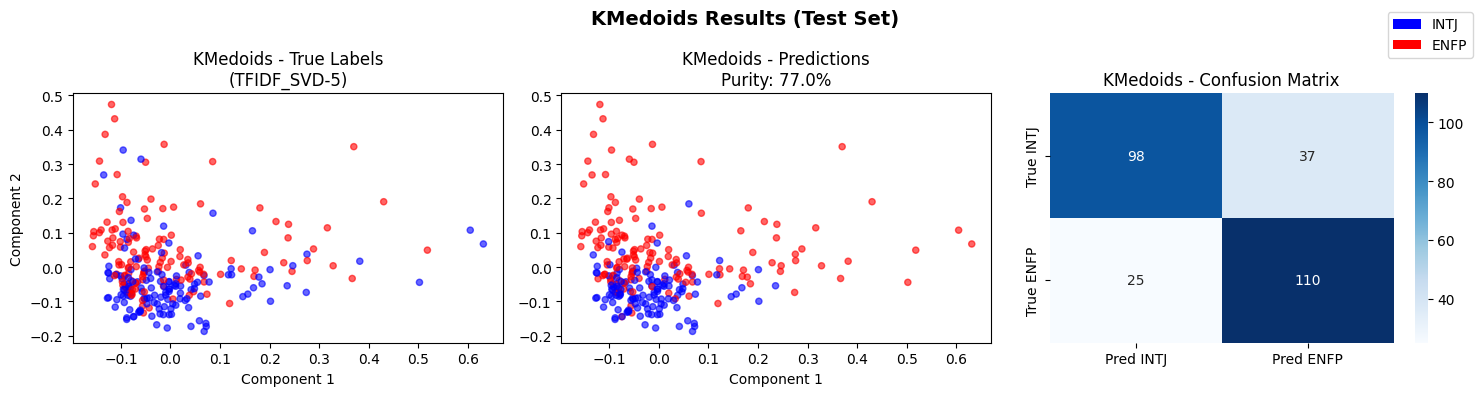

In [33]:
if best_kmed is not None:
    kmed_config = best_kmed['Config']
    X_test_kmed = all_configs_test[kmed_config]
    X_train_kmed = all_configs_train[kmed_config]
    X_2d = get_2d_data(X_test_kmed)
    
    # Fit model and get predictions
    kmed_model = KMedoids(n_clusters=2, metric=best_kmed['metric'], 
                         init=best_kmed['init'], random_state=42)
    kmed_model.fit(X_train_kmed)
    kmed_pred = kmed_model.predict(X_test_kmed)
    
    # Map clusters to labels
    cluster_map = {}
    for c in np.unique(kmed_pred):
        mask = kmed_pred == c
        cluster_map[c] = pd.Series(y_test[mask]).mode()[0]
    kmed_mapped = np.array([cluster_map[c] for c in kmed_pred])
    
    # Create KMedoids figure
    fig_kmed, axes_kmed = plt.subplots(1, 3, figsize=(15, 4))
    
    # True labels
    colors_true = ['blue' if l == 'INTJ' else 'red' for l in y_test]
    axes_kmed[0].scatter(X_2d[:, 0], X_2d[:, 1], c=colors_true, alpha=0.6, s=20)
    axes_kmed[0].set_title(f'KMedoids - True Labels\n({kmed_config})')
    axes_kmed[0].set_xlabel('Component 1')
    axes_kmed[0].set_ylabel('Component 2')
    
    # Predicted clusters
    colors_pred = ['blue' if l == 'INTJ' else 'red' for l in kmed_mapped]
    axes_kmed[1].scatter(X_2d[:, 0], X_2d[:, 1], c=colors_pred, alpha=0.6, s=20)
    purity = (kmed_mapped == y_test).mean()
    axes_kmed[1].set_title(f'KMedoids - Predictions\nPurity: {purity:.1%}')
    axes_kmed[1].set_xlabel('Component 1')
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, kmed_mapped, labels=['INTJ', 'ENFP'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_kmed[2],
                xticklabels=['Pred INTJ', 'Pred ENFP'],
                yticklabels=['True INTJ', 'True ENFP'])
    axes_kmed[2].set_title('KMedoids - Confusion Matrix')
    
    legend_elements = [Patch(facecolor='blue', label='INTJ'),
                       Patch(facecolor='red', label='ENFP')]
    fig_kmed.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))
    
    plt.suptitle('KMedoids Results (Test Set)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

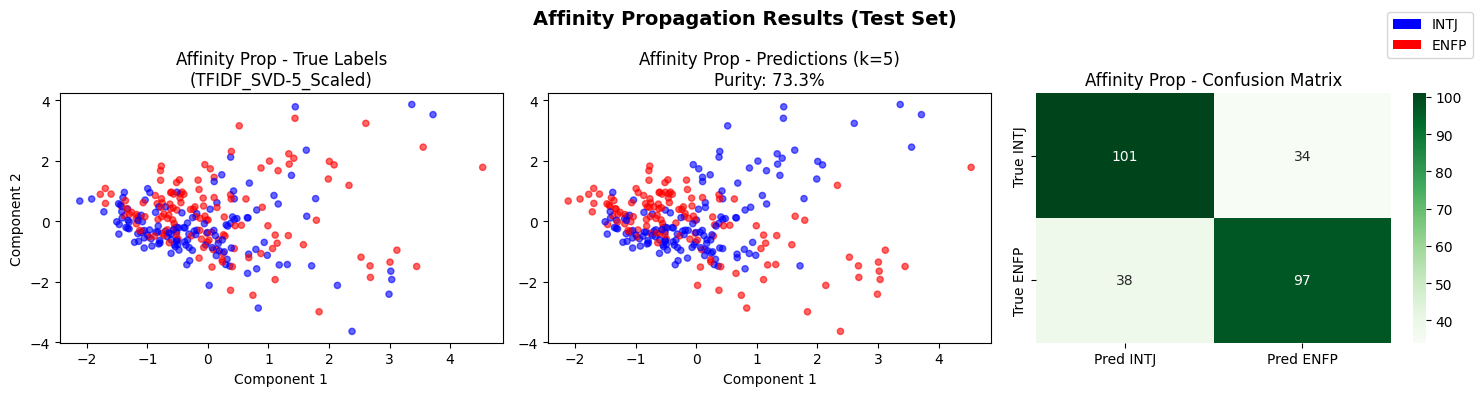

In [34]:
if best_af is not None:
    af_config = best_af['Config']
    X_test_af = all_configs_test[af_config]
    X_train_af = all_configs_train[af_config]
    X_2d_af = get_2d_data(X_test_af)
    
    af_model = AffinityPropagation(damping=best_af['damping'], preference=best_af['preference'], random_state=42)
    af_model.fit(X_train_af)
    af_pred = af_model.predict(X_test_af)
    
    # Map clusters to labels
    cluster_map_af = {}
    for c in np.unique(af_pred):
        mask = af_pred == c
        if sum(mask) > 0:
            cluster_map_af[c] = pd.Series(y_test[mask]).mode()[0]
    af_mapped = np.array([cluster_map_af.get(c, 'INTJ') for c in af_pred])
    
    fig_af, axes_af = plt.subplots(1, 3, figsize=(15, 4))
    
    # True labels
    colors_true = ['blue' if l == 'INTJ' else 'red' for l in y_test]
    axes_af[0].scatter(X_2d_af[:, 0], X_2d_af[:, 1], c=colors_true, alpha=0.6, s=20)
    axes_af[0].set_title(f'Affinity Prop - True Labels\n({af_config})')
    axes_af[0].set_xlabel('Component 1')
    axes_af[0].set_ylabel('Component 2')
    
    # Predicted clusters
    colors_pred = ['blue' if l == 'INTJ' else 'red' for l in af_mapped]
    axes_af[1].scatter(X_2d_af[:, 0], X_2d_af[:, 1], c=colors_pred, alpha=0.6, s=20)
    purity_af = (af_mapped == y_test).mean()
    axes_af[1].set_title(f'Affinity Prop - Predictions (k={len(np.unique(af_pred))})\nPurity: {purity_af:.1%}')
    axes_af[1].set_xlabel('Component 1')
    
    # Confusion Matrix
    cm_af = confusion_matrix(y_test, af_mapped, labels=['INTJ', 'ENFP'])
    sns.heatmap(cm_af, annot=True, fmt='d', cmap='Greens', ax=axes_af[2],
                xticklabels=['Pred INTJ', 'Pred ENFP'],
                yticklabels=['True INTJ', 'True ENFP'])
    axes_af[2].set_title('Affinity Prop - Confusion Matrix')
    
    legend_elements = [Patch(facecolor='blue', label='INTJ'),
                       Patch(facecolor='red', label='ENFP')]
    fig_af.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))
    
    plt.suptitle('Affinity Propagation Results (Test Set)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Supervised approaches

In [35]:
X_2d_sup = get_2d_data(X_test_sup)
lr_pred = lr.predict(X_test_sup)
svm_pred = svm.predict(X_test_sup)

plot_data = {
    'X_2d': X_2d_sup,
    'y_true': y_test_enc,
    'lr_pred': lr_pred,
    'svm_pred': svm_pred,
    'lr_acc': lr_acc,
    'svm_acc': svm_acc,
    'config': sup_config
}

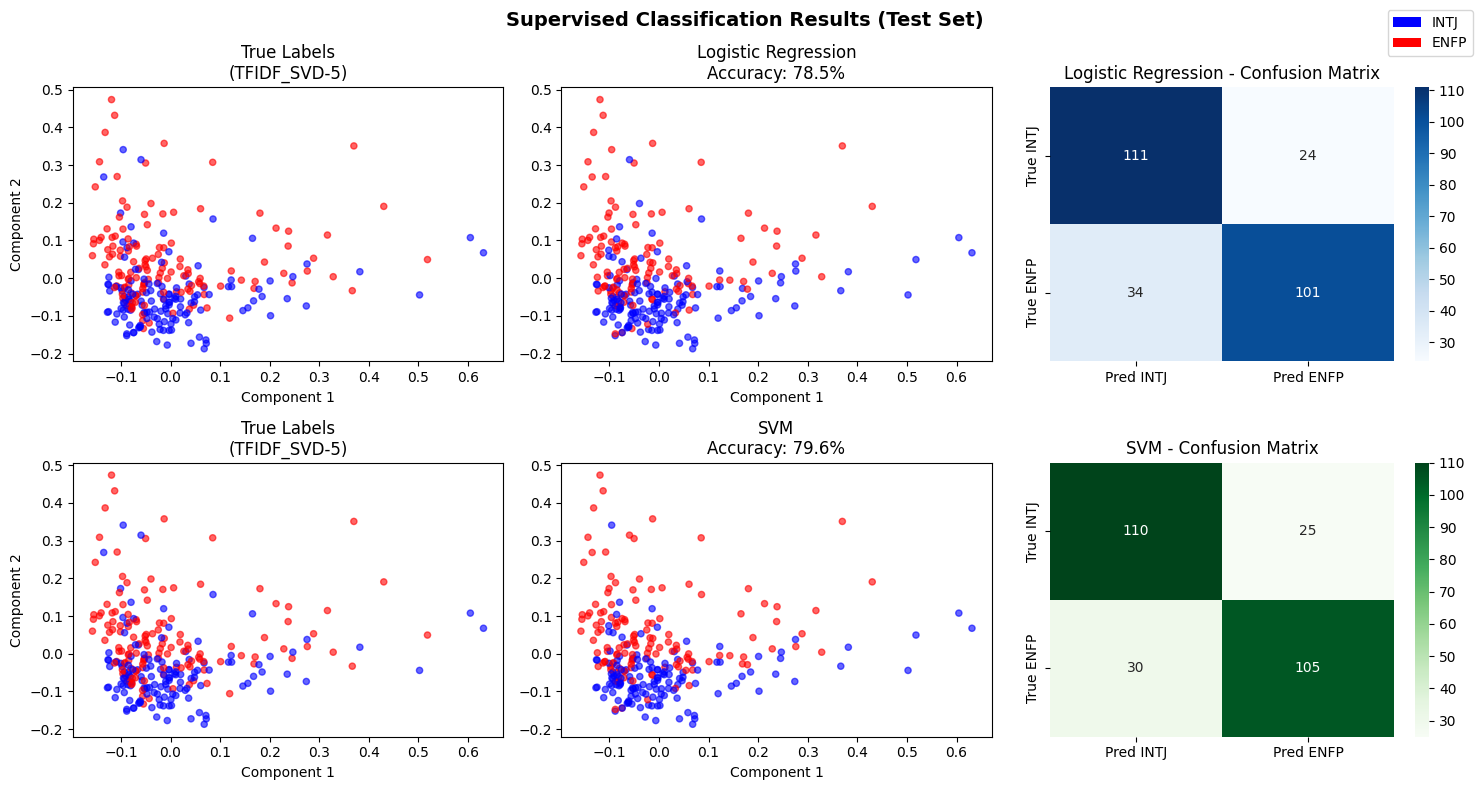

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

#Logistic Regression
colors_true = ['blue' if l == 1 else 'red' for l in plot_data['y_true']]
axes[0,0].scatter(plot_data['X_2d'][:, 0], plot_data['X_2d'][:, 1], 
                 c=colors_true, alpha=0.6, s=20)
axes[0,0].set_title(f'True Labels\n({plot_data["config"]})')
axes[0,0].set_xlabel('Component 1')
axes[0,0].set_ylabel('Component 2')

colors_lr = ['blue' if l == 1 else 'red' for l in plot_data['lr_pred']]
axes[0,1].scatter(plot_data['X_2d'][:, 0], plot_data['X_2d'][:, 1], 
                 c=colors_lr, alpha=0.6, s=20)
axes[0,1].set_title(f'Logistic Regression\nAccuracy: {plot_data["lr_acc"]:.1%}')
axes[0,1].set_xlabel('Component 1')

cm_lr = confusion_matrix(plot_data['y_true'], plot_data['lr_pred'], labels=[1, 0])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
            xticklabels=['Pred INTJ', 'Pred ENFP'],
            yticklabels=['True INTJ', 'True ENFP'])
axes[0,2].set_title('Logistic Regression - Confusion Matrix')

#SVM
axes[1,0].scatter(plot_data['X_2d'][:, 0], plot_data['X_2d'][:, 1], 
                 c=colors_true, alpha=0.6, s=20)
axes[1,0].set_title(f'True Labels\n({plot_data["config"]})')
axes[1,0].set_xlabel('Component 1')
axes[1,0].set_ylabel('Component 2')

colors_svm = ['blue' if l == 1 else 'red' for l in plot_data['svm_pred']]
axes[1,1].scatter(plot_data['X_2d'][:, 0], plot_data['X_2d'][:, 1], 
                 c=colors_svm, alpha=0.6, s=20)
axes[1,1].set_title(f'SVM\nAccuracy: {plot_data["svm_acc"]:.1%}')
axes[1,1].set_xlabel('Component 1')

cm_svm = confusion_matrix(plot_data['y_true'], plot_data['svm_pred'], labels=[1, 0])
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1,2],
            xticklabels=['Pred INTJ', 'Pred ENFP'],
            yticklabels=['True INTJ', 'True ENFP'])
axes[1,2].set_title('SVM - Confusion Matrix')

legend_elements = [Patch(facecolor='blue', label='INTJ'),
                   Patch(facecolor='red', label='ENFP')]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))

plt.suptitle('Supervised Classification Results (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cluster interpretation

## K-medoids

In [37]:
kmed_model_interp = KMedoids(n_clusters=2, metric=best_kmed['metric'], 
                              init=best_kmed['init'], random_state=42)
kmed_model_interp.fit(all_configs_train[best_kmed['Config']])
train_clusters = kmed_model_interp.predict(all_configs_train[best_kmed['Config']])

print("\n Cluster Composition")
for c in [0, 1]:
    mask = train_clusters == c
    intj_count = sum(y_train[mask] == 'INTJ')
    enfp_count = sum(y_train[mask] == 'ENFP')
    total = sum(mask)
    majority = 'INTJ' if intj_count > enfp_count else 'ENFP'
    print(f"Cluster {c}: {total} samples ({intj_count} INTJ, {enfp_count} ENFP) -> Majority: {majority}")

print("\n Top Words per Cluster")
feature_names = tfidf.get_feature_names_out()

# Get cluster centers
medoid_indices = kmed_model_interp.medoid_indices_
for c, medoid_idx in enumerate(medoid_indices):
    medoid_tfidf = X_tfidf_train[medoid_idx].toarray().flatten()
    top_indices = medoid_tfidf.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    
    mask = train_clusters == c
    majority = 'INTJ' if sum(y_train[mask] == 'INTJ') > sum(y_train[mask] == 'ENFP') else 'ENFP'
    
    print(f"\nCluster {c} (majority {majority}):")
    print(f"  Top words: {', '.join(top_words)}")



 Cluster Composition
Cluster 0: 499 samples (394 INTJ, 105 ENFP) -> Majority: INTJ
Cluster 1: 581 samples (146 INTJ, 435 ENFP) -> Majority: ENFP

 Top Words per Cluster

Cluster 0 (majority INTJ):
  Top words: 16, middle, somewhat, speaking, brother, sister, maybe, school, law, stories

Cluster 1 (majority ENFP):
  Top words: gonna, laughing, dear, bit, guys, make, ve, quite, warm, usually


In [38]:
features_train = features_df.iloc[train_idx].copy()
features_train['cluster'] = train_clusters
features_train['true_type'] = y_train
cluster_means = features_train.groupby('cluster')[features_df.columns].mean()

diff = abs(cluster_means.loc[0] - cluster_means.loc[1])
top_diff = diff.sort_values(ascending=False).head(10)
print("\nMost distinguishing features: \n")
for feat, val in top_diff.items():
    print(f"  {feat}: Cluster0={cluster_means.loc[0, feat]:.4f}, Cluster1={cluster_means.loc[1, feat]:.4f}")


Most distinguishing features: 

  avg_word_length: Cluster0=4.1318, Cluster1=3.9900
  avg_sentence_length: Cluster0=11.3814, Cluster1=11.2533
  exclamation_rate: Cluster0=0.0494, Cluster1=0.1367
  excl_to_period: Cluster0=0.0351, Cluster1=0.1056
  struct_vs_express: Cluster0=0.3410, Cluster1=0.4060
  sentence_rhythm_cv: Cluster0=0.7219, Cluster1=0.7576
  unique_word_ratio: Cluster0=0.4187, Cluster1=0.3912
  short_sentence_rate: Cluster0=0.2840, Cluster1=0.3083
  long_word_rate: Cluster0=0.1611, Cluster1=0.1420
  multiple_exclamation_rate: Cluster0=0.0033, Cluster1=0.0169


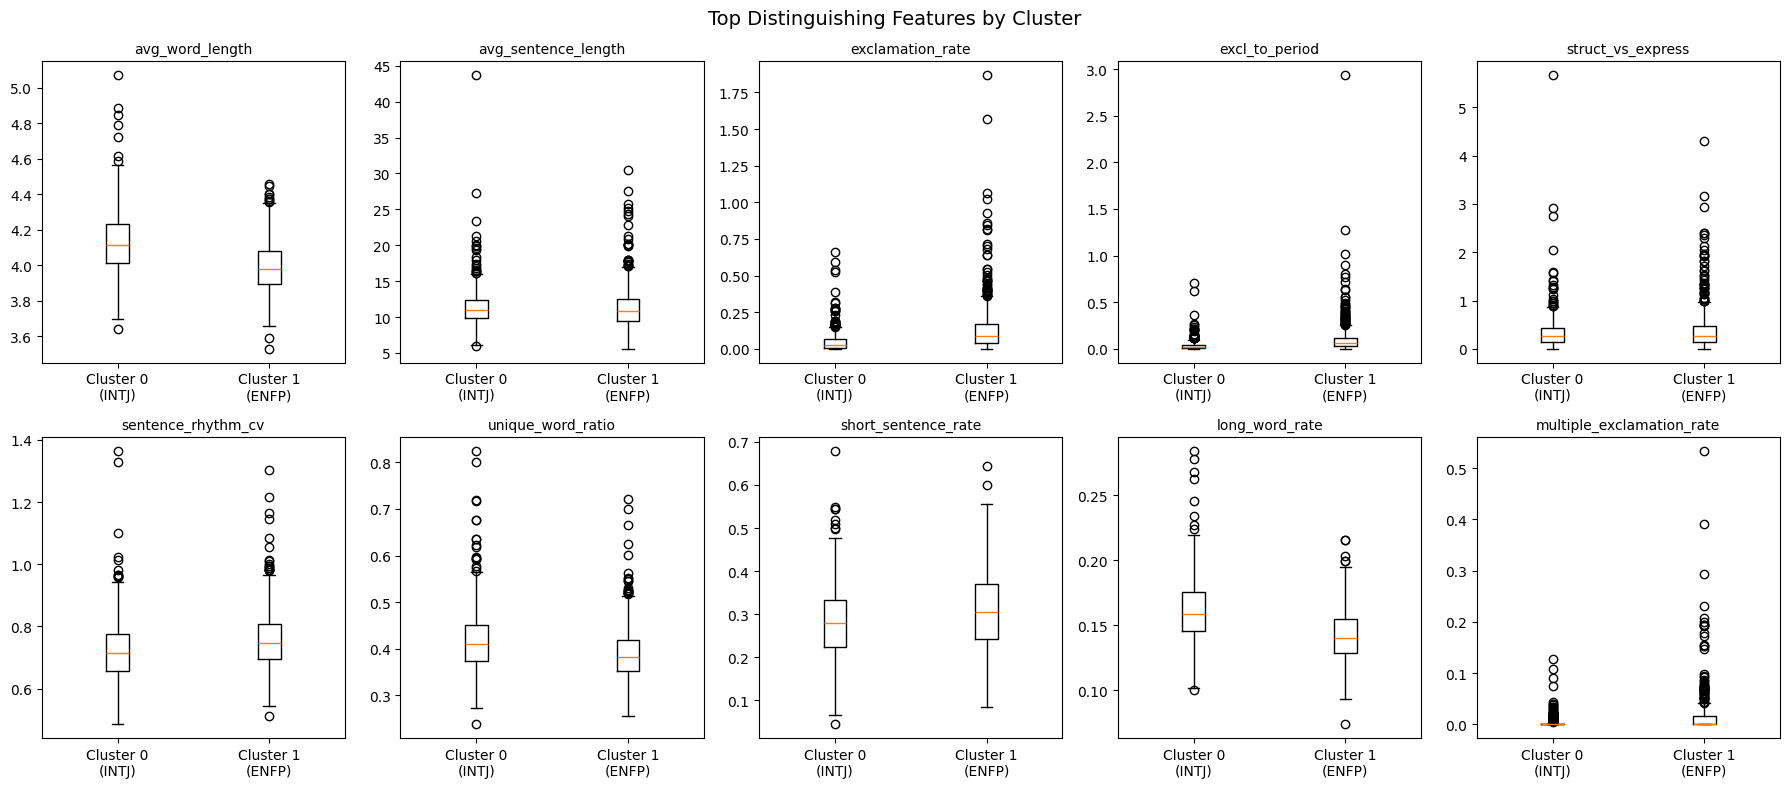

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top_diff.index[:10]):
    data_c0 = features_train[features_train['cluster'] == 0][feat]
    data_c1 = features_train[features_train['cluster'] == 1][feat]
    
    axes[i].boxplot([data_c0, data_c1], labels=['Cluster 0\n(INTJ)', 'Cluster 1\n(ENFP)'])
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Top Distinguishing Features by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
enfp_in_intj_cluster = (train_clusters == 0) & (y_train == 'ENFP')
intj_in_enfp_cluster = (train_clusters == 1) & (y_train == 'INTJ')

print(f"ENFPs misplaced in INTJ cluster: {sum(enfp_in_intj_cluster)}")
print(f"INTJs misplaced in ENFP cluster: {sum(intj_in_enfp_cluster)}")

print("\nMisclassified ENFP features (in INTJ cluster) vs Correct ENFP:")
correct_enfp = (train_clusters == 1) & (y_train == 'ENFP')

for feat in top_diff.index[:5]:
    mis_mean = features_train.loc[enfp_in_intj_cluster, feat].mean()
    cor_mean = features_train.loc[correct_enfp, feat].mean()
    print(f"  {feat}: Misclassified={mis_mean:.4f}, Correct={cor_mean:.4f}")

ENFPs misplaced in INTJ cluster: 105
INTJs misplaced in ENFP cluster: 146

Misclassified ENFP features (in INTJ cluster) vs Correct ENFP:
  avg_word_length: Misclassified=4.0786, Correct=3.9702
  avg_sentence_length: Misclassified=11.6257, Correct=11.2348
  exclamation_rate: Misclassified=0.0815, Correct=0.1554
  excl_to_period: Misclassified=0.0573, Correct=0.1207
  struct_vs_express: Misclassified=0.3077, Correct=0.3934


## Affinity propagation

In [41]:
af_model_interp = AffinityPropagation(damping=best_af['damping'],preference=best_af['preference'],random_state=42)
af_model_interp.fit(all_configs_train[best_af['Config']])
train_clusters_af = af_model_interp.labels_

print(f"\nAffinity Propagation Results ({best_af['Config']})")
print(f"Number of clusters found: {len(np.unique(train_clusters_af))}")

# Cluster composition
print("\nCluster Composition:")
for c in np.unique(train_clusters_af):
    mask = train_clusters_af == c
    intj_count = sum(y_train[mask] == 'INTJ')
    enfp_count = sum(y_train[mask] == 'ENFP')
    total = sum(mask)
    
    if total > 0:
        majority = 'INTJ' if intj_count > enfp_count else 'ENFP'
        majority_pct = max(intj_count, enfp_count) / total * 100
        print(f"Cluster {c}: {total:>3} samples ({intj_count:>3} INTJ, {enfp_count:>3} ENFP) -> {majority} ({majority_pct:.1f}%)")


Affinity Propagation Results (TFIDF_SVD-5_Scaled)
Number of clusters found: 5

Cluster Composition:
Cluster 0: 383 samples ( 90 INTJ, 293 ENFP) -> ENFP (76.5%)
Cluster 1: 387 samples (306 INTJ,  81 ENFP) -> INTJ (79.1%)
Cluster 2:  68 samples ( 25 INTJ,  43 ENFP) -> ENFP (63.2%)
Cluster 3: 149 samples ( 84 INTJ,  65 ENFP) -> INTJ (56.4%)
Cluster 4:  93 samples ( 35 INTJ,  58 ENFP) -> ENFP (62.4%)


In [42]:
print("\nExemplar Analysis:")
exemplar_indices = af_model_interp.cluster_centers_indices_

for c, exemplar_idx in enumerate(exemplar_indices):
    mask = train_clusters_af == c
    majority = 'INTJ' if sum(y_train[mask] == 'INTJ') > sum(y_train[mask] == 'ENFP') else 'ENFP'
    
    print(f"\nCluster {c} (exemplar index {exemplar_idx}, majority {majority}):")
    
    # Top TF-IDF words for exemplar
    exemplar_tfidf = X_tfidf_train[exemplar_idx].toarray().flatten()
    top_indices = exemplar_tfidf.argsort()[-8:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"  Top words: {', '.join(top_words)}")
    
    exemplar_post = df_balanced.iloc[train_idx[exemplar_idx]]['posts_clean']
    snippet = exemplar_post[:150] + "..." if len(exemplar_post) > 150 else exemplar_post


Exemplar Analysis:

Cluster 0 (exemplar index 7, majority ENFP):
  Top words: glad, weird, unhealthy, helped, favorite, finally, character, music

Cluster 1 (exemplar index 198, majority INTJ):
  Top words: 16, middle, somewhat, speaking, brother, sister, maybe, school

Cluster 2 (exemplar index 254, majority ENFP):
  Top words: shit, thats, im, music, laugh, alot, listen, say

Cluster 3 (exemplar index 528, majority INTJ):
  Top words: introverted, functions, don, asking, type, kind, intuitive, looked

Cluster 4 (exemplar index 662, majority ENFP):
  Top words: somebody, perc, love, female, scared, welcome, results, tongue


In [43]:
print("\nOverall Statistics:")
print(f"Total clusters: {len(np.unique(train_clusters_af))}")
print(f"Cluster sizes: {np.bincount(train_clusters_af + 1)}")

# purity
purity = 0
for c in np.unique(train_clusters_af):
    mask = train_clusters_af == c
    if sum(mask) > 0:
        majority_label = pd.Series(y_train[mask]).mode()[0]
        purity += sum(y_train[mask] == majority_label)
purity = purity / len(y_train)
print(f"Overall purity: {purity:.1%}")

print("\nCluster Purity:")
for c in np.unique(train_clusters_af):
    mask = train_clusters_af == c
    if sum(mask) > 0:
        intj_pct = sum(y_train[mask] == 'INTJ') / sum(mask) * 100
        enfp_pct = sum(y_train[mask] == 'ENFP') / sum(mask) * 100
        purity_score = max(intj_pct, enfp_pct)
        print(f"Cluster {c}: {purity_score:.1f}% pure ({intj_pct:.0f}% INTJ, {enfp_pct:.0f}% ENFP)")


Overall Statistics:
Total clusters: 5
Cluster sizes: [  0 383 387  68 149  93]
Overall purity: 72.6%

Cluster Purity:
Cluster 0: 76.5% pure (23% INTJ, 77% ENFP)
Cluster 1: 79.1% pure (79% INTJ, 21% ENFP)
Cluster 2: 63.2% pure (37% INTJ, 63% ENFP)
Cluster 3: 56.4% pure (56% INTJ, 44% ENFP)
Cluster 4: 62.4% pure (38% INTJ, 62% ENFP)


# Final comparison

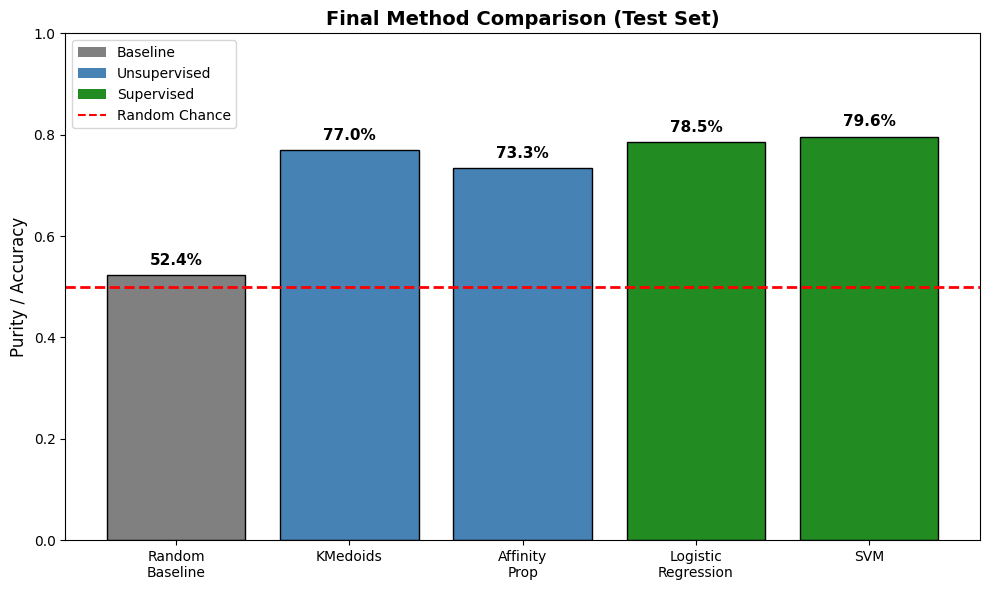

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Random\nBaseline', 'KMedoids', 'Affinity\nProp', 'Logistic\nRegression', 'SVM']
performances = [
    np.mean(random_purities),
    kmed_results['purity'],
    af_results['purity'] if af_results else 0.5,
    lr_acc,
    svm_acc
]
colors = ['gray', 'steelblue', 'steelblue', 'forestgreen', 'forestgreen']

bars = ax.bar(methods, performances, color=colors, edgecolor='black')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Random Chance (50%)')
ax.set_ylabel('Purity / Accuracy', fontsize=12)
ax.set_title('Final Method Comparison (Test Set)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])

for bar, val in zip(bars, performances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

legend_elements = [
    Patch(facecolor='gray', label='Baseline'),
    Patch(facecolor='steelblue', label='Unsupervised'),
    Patch(facecolor='forestgreen', label='Supervised'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Random Chance')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()